In [16]:
import sys
sys.path.append("/home/user/문서/workspace/python/src")

from data_load_save import *


In [17]:
csv_file = f"/home/user/문서/workspace/python/data/콩_무역_2023.csv"

df = pd.read_csv(csv_file)

df.head()

,importer,exporter,value
0,"China, mainland",Brazil,71592496.82
1,"China, mainland",United States of America,26506551.32
2,Argentina,Paraguay,5829120.00
3,Argentina,Brazil,4081112.10
4,Thailand,Brazil,2750180.24


In [18]:
import pandas as pd
import networkx as nx
import itertools
import community  # python-louvain (import community.community_louvain as community_louvain 라고 쓰기도 함)


# 1) 데이터 불러와서 방향 + 가중 네트워크 만들기
def build_trade_network(csv_path, src_col="exporter", dst_col="importer", w_col="value"):
    df = pd.read_csv(csv_path)
    # 0 이상인 값만 사용 (필요시 필터)
    df = df[df[w_col] > 0].copy()
    
    G = nx.DiGraph()
    for _, row in df.iterrows():
        src = row[src_col]
        dst = row[dst_col]
        w = float(row[w_col])
        # 이미 간선 있으면 weight 누적
        if G.has_edge(src, dst):
            G[src][dst]["weight"] += w
        else:
            G.add_edge(src, dst, weight=w)
    return G


# 2) 기본 네트워크 특성 계산
def compute_basic_measures(G):
    print("=== Basic topology ===")
    N = G.number_of_nodes()
    M = G.number_of_edges()
    print(f"Nodes (N): {N}")
    print(f"Edges (M): {M}")
    
    # Network density (directional)
    density = nx.density(G)
    print(f"Density ρ: {density:.4f}")
    
    # 평균 경로 길이 & 직경: 약하게 연결된 최대 컴포넌트에서 계산 (무향으로 변환)
    if N > 0:
        H = G.to_undirected()
        largest_cc_nodes = max(nx.connected_components(H), key=len)
        H_cc = H.subgraph(largest_cc_nodes).copy()
        
        if H_cc.number_of_nodes() > 1:
            L = nx.average_shortest_path_length(H_cc)
            Dia = nx.diameter(H_cc)
            print(f"Average path length L (on largest component): {L:.4f}")
            print(f"Network diameter Dia (on largest component): {Dia}")
        else:
            print("Largest component has only 1 node, cannot compute L/Dia.")
    
    # Degree / Weighted degree
    print("\n=== Degree / Weighted degree (sample) ===")
    # out-degree, in-degree (weighted)
    out_wdeg = G.out_degree(weight="weight")
    in_wdeg = G.in_degree(weight="weight")
    # 그냥 몇 개만 보기
    for n, w in list(out_wdeg)[:5]:
        print(f"{n}: weighted outdegree = {w}")
    for n, w in list(in_wdeg)[:5]:
        print(f"{n}: weighted indegree = {w}")
    
    # Betweenness centrality (unweighted shortest path 기준)
    print("\n=== Betweenness centrality (top 5) ===")
    bc = nx.betweenness_centrality(G, normalized=True, weight=None)
    for n, v in sorted(bc.items(), key=lambda x: x[1], reverse=True)[:5]:
        print(f"{n}: BC = {v:.4f}")
    
    # Closeness centrality (무향 변환 후)
    print("\n=== Closeness centrality (top 5, undirected) ===")
    cc = nx.closeness_centrality(G.to_undirected())
    for n, v in sorted(cc.items(), key=lambda x: x[1], reverse=True)[:5]:
        print(f"{n}: CC = {v:.4f}")
    
    # Clustering coefficient (무향)
    print("\n=== Clustering coefficient ===")
    clustering = nx.clustering(G.to_undirected(), weight=None)
    avg_clustering = sum(clustering.values()) / len(clustering) if clustering else 0
    print(f"Average clustering coefficient: {avg_clustering:.4f}")
    
    return {
        "density": density,
        "weighted_outdegree": dict(out_wdeg),
        "weighted_indegree": dict(in_wdeg),
        "betweenness": bc,
        "closeness": cc,
        "clustering": clustering,
    }



# 3) 모듈성 Q & 커뮤니티 (Louvain)
def compute_modularity_and_communities(G):
    print("\n=== Louvain community detection & modularity Q ===")
    H = G.to_undirected()
    
    # Louvain partition: node -> community_id
    partition = community.best_partition(H, weight="weight")
    # Modularity Q
    Q = community.modularity(partition, H, weight="weight")
    print(f"Modularity Q: {Q:.4f}")
    
    # 커뮤니티 예시 출력
    communities = {}
    for node, com in partition.items():
        communities.setdefault(com, []).append(node)
    
    print(f"Number of communities: {len(communities)}")
    for cid, nodes in list(communities.items())[:3]:
        print(f"Community {cid}: {nodes[:10]}{'...' if len(nodes) > 10 else ''}")
    
    return partition, Q


# 4) HITS hub / authority
def compute_hits(G, max_iter=1000, tol=1e-08):
    print("\n=== HITS hub / authority (top 5) ===")
    hubs, authorities = nx.hits(G, max_iter=max_iter, tol=tol, normalized=True)
    
    print("Top hubs:")
    for n, v in sorted(hubs.items(), key=lambda x: x[1], reverse=True)[:5]:
        print(f"{n}: hub = {v:.4f}")
    
    print("Top authorities:")
    for n, v in sorted(authorities.items(), key=lambda x: x[1], reverse=True)[:5]:
        print(f"{n}: auth = {v:.4f}")
    
    return hubs, authorities


# 5) Network efficiency E
def network_efficiency(G):
    """
    E = 1 / [n(n-1)] * sum_{i != j} 1/d_ij
    여기서는 무향 그래프의 최단경로 기준으로 계산
    """
    H = G.to_undirected()
    nodes = list(H.nodes())
    n = len(nodes)
    if n < 2:
        return 0.0
    
    eff_sum = 0.0
    pair_count = 0
    
    for i, j in itertools.combinations(nodes, 2):
        try:
            d = nx.shortest_path_length(H, i, j)
            eff_sum += 1.0 / d
            pair_count += 1
        except nx.NetworkXNoPath:
            # 연결 안되어 있으면 그 쌍은 기여 0으로 처리
            continue
    
    if pair_count == 0:
        return 0.0
    
    # 위에서 i<j 조합만 돌렸으므로 분모는 n(n-1)/2 → 논문식에 맞추면:
    # E = (2 * eff_sum) / [n(n-1)]
    E = (2.0 * eff_sum) / (n * (n - 1))
    return E


def compute_robustness_scenarios(G, remove_sets):
    """
    remove_sets: 예) {"Scenario 1 (remove Brazil)": ["Brazil"], "Scenario 2 (remove USA)": ["USA"]}
    """
    print("\n=== Network efficiency robustness scenarios ===")
    baseline_E = network_efficiency(G)
    print(f"Baseline E: {baseline_E:.4f}")
    
    results = {"Baseline": baseline_E}
    
    for name, nodes_to_remove in remove_sets.items():
        G_copy = G.copy()
        G_copy.remove_nodes_from(nodes_to_remove)
        E_val = network_efficiency(G_copy)
        print(f"{name}: remove {nodes_to_remove} → E = {E_val:.4f}")
        results[name] = E_val
    return results



In [19]:
# ======================================================
# 0. Imports
# ======================================================
import pandas as pd
import numpy as np
import networkx as nx


# ======================================================
# 1. 네트워크 구축
# ======================================================
def build_trade_network(csv_path, src_col, dst_col, w_col):
    df = pd.read_csv(csv_path)

    G = nx.DiGraph()
    for _, r in df.iterrows():
        G.add_edge(
            r[src_col],
            r[dst_col],
            weight=float(r[w_col])
        )
    return G


# ======================================================
# 2. 기본 지표 계산
# ======================================================
def compute_basic_measures(G):
    return {
        "degree": dict(G.degree()),
        "weighted_outdegree": dict(G.out_degree(weight="weight")),
        "weighted_indegree": dict(G.in_degree(weight="weight")),
        "betweenness": nx.betweenness_centrality(G, weight="weight", normalized=True),
        "closeness": nx.closeness_centrality(G),
    }


# ======================================================
# 3. 커뮤니티 & 모듈성
# ======================================================
def compute_modularity_and_communities(G):
    UG = G.to_undirected()
    communities = nx.algorithms.community.louvain_communities(
        UG, weight="weight", seed=42
    )
    modularity = nx.algorithms.community.modularity(
        UG, communities, weight="weight"
    )

    partition = {}
    for i, com in enumerate(communities):
        for n in com:
            partition[n] = i

    return partition, modularity


# ======================================================
# 4. HITS
# ======================================================
def compute_hits(G):
    hubs, authorities = nx.hits(G, max_iter=1000, normalized=True)
    return hubs, authorities


# ======================================================
# 5. 네트워크 효율성
# ======================================================
def network_efficiency(G):
    UG = G.to_undirected()
    nodes = list(UG.nodes())
    n = len(nodes)

    if n <= 1:
        return 0.0

    eff = 0.0
    for i in range(n):
        for j in range(i + 1, n):
            try:
                d = nx.shortest_path_length(UG, nodes[i], nodes[j])
                eff += 1 / d
            except nx.NetworkXNoPath:
                pass

    return eff * 2 / (n * (n - 1))


# ======================================================
# 6. 연도별 네트워크 요약 테이블
# ======================================================
def summarize_network(G, year, modularity):
    N = G.number_of_nodes()
    M = G.number_of_edges()

    degrees = dict(G.degree())
    w_degrees = dict(G.degree(weight="weight"))

    avg_degree = np.mean(list(degrees.values()))
    avg_w_degree = np.mean(list(w_degrees.values()))

    density = nx.density(G)
    clustering = nx.average_clustering(G.to_undirected())

    # 🔑 경로 관련 지표는 Undirected + Largest WCC
    UG = G.to_undirected()

    if nx.is_connected(UG):
        L = nx.average_shortest_path_length(UG)
        Dia = nx.diameter(UG)
    else:
        giant = UG.subgraph(max(nx.connected_components(UG), key=len))
        L = nx.average_shortest_path_length(giant)
        Dia = nx.diameter(giant)

    return {
        "Year": year,
        "Average Degree": round(avg_degree, 3),
        "Average Weighted Degree": round(avg_w_degree, 1),
        "Network Diameter": Dia,
        "Graph Density": round(density, 3),
        "Average Clustering Coefficient": round(clustering, 3),
        "Average Path Length": round(L, 3),
        "Nodes": N,
        "Edges": M,
        "Modularity": round(modularity, 3),
    }



# ======================================================
# 7. 시나리오 분석 테이블 (China 기준)
# ======================================================
def summarize_scenario_results(
    benchmark_G,
    scenario_graphs,
    target_node="China",
    year=2022,
):
    rows = []

    # ==================================================
    # Benchmark
    # ==================================================
    bc0 = nx.betweenness_centrality(benchmark_G, weight="weight")
    cc0 = nx.closeness_centrality(benchmark_G)

    # 🔑 Undirected + Largest Connected Component
    UG0 = benchmark_G.to_undirected()
    if nx.is_connected(UG0):
        giant0 = UG0
    else:
        giant0 = UG0.subgraph(max(nx.connected_components(UG0), key=len))

    L0 = nx.average_shortest_path_length(giant0)
    E0 = network_efficiency(benchmark_G)

    rows.append({
        "Scenario": f"Benchmark year—{year}",
        "Closeness Centrality": round(cc0.get(target_node, np.nan), 3),
        "Betweenness Centrality": round(bc0.get(target_node, np.nan) * 1000, 3),
        "Average Path Length": round(L0, 3),
        "Network Efficiency": round(E0, 3),
    })

    # ==================================================
    # Scenarios
    # ==================================================
    for name, Gs in scenario_graphs.items():
        bc = nx.betweenness_centrality(Gs, weight="weight")
        cc = nx.closeness_centrality(Gs)

        UG = Gs.to_undirected()
        if nx.is_connected(UG):
            giant = UG
        else:
            giant = UG.subgraph(max(nx.connected_components(UG), key=len))

        L = nx.average_shortest_path_length(giant)
        E = network_efficiency(Gs)

        rows.append({
            "Scenario": name,
            "Closeness Centrality": round(cc.get(target_node, np.nan), 3),
            "Betweenness Centrality": round(bc.get(target_node, np.nan) * 1000, 3),
            "Average Path Length": round(L, 3),
            "Network Efficiency": round(E, 3),
        })

    return pd.DataFrame(rows)


# ======================================================
# 8. 실행부
# ======================================================
csv_path = "/home/user/문서/workspace/python/data/콩_무역_2023.csv"

G = build_trade_network(
    csv_path,
    src_col="exporter",
    dst_col="importer",
    w_col="value",
)

measures = compute_basic_measures(G)
partition, Q = compute_modularity_and_communities(G)
hubs, authorities = compute_hits(G)

# ---- 네트워크 요약 테이블
summary_row = summarize_network(G, year=2022, modularity=Q)
df_network_summary = pd.DataFrame([summary_row])
print("\n=== Network summary ===")
print(df_network_summary)

# ---- 시나리오 네트워크
scenario_graphs = {}
scenario_def = {
    "Scenario 1—Brazil excluded": ["Brazil"],
    "Scenario 2—US excluded": ["USA"],
    "Scenario 3—Brazil & US excluded": ["Brazil", "USA"],
}

for name, remove_nodes in scenario_def.items():
    Gs = G.copy()
    Gs.remove_nodes_from([n for n in remove_nodes if n in Gs])
    scenario_graphs[name] = Gs

# ---- 시나리오 테이블
df_scenarios = summarize_scenario_results(
    G,
    scenario_graphs,
    target_node="China",
    year=2022,
)

print("\n=== Scenario analysis (China) ===")
print(df_scenarios)

# ---- LaTeX 바로 출력하고 싶으면
# print(df_network_summary.to_latex(index=False))
# print(df_scenarios.to_latex(index=False))



=== Network summary ===
   Year  Average Degree  Average Weighted Degree  Network Diameter  \
0  2022          14.085                2217243.4                 5   

   Graph Density  Average Clustering Coefficient  Average Path Length  Nodes  \
0           0.05                           0.468                2.337    142   

   Edges  Modularity  
0   1000       0.128  

=== Scenario analysis (China) ===
                          Scenario  Closeness Centrality  \
0              Benchmark year—2022                   NaN   
1       Scenario 1—Brazil excluded                   NaN   
2           Scenario 2—US excluded                   NaN   
3  Scenario 3—Brazil & US excluded                   NaN   

   Betweenness Centrality  Average Path Length  Network Efficiency  
0                     NaN                2.337               0.475  
1                     NaN                2.347               0.472  
2                     NaN                2.337               0.475  
3              

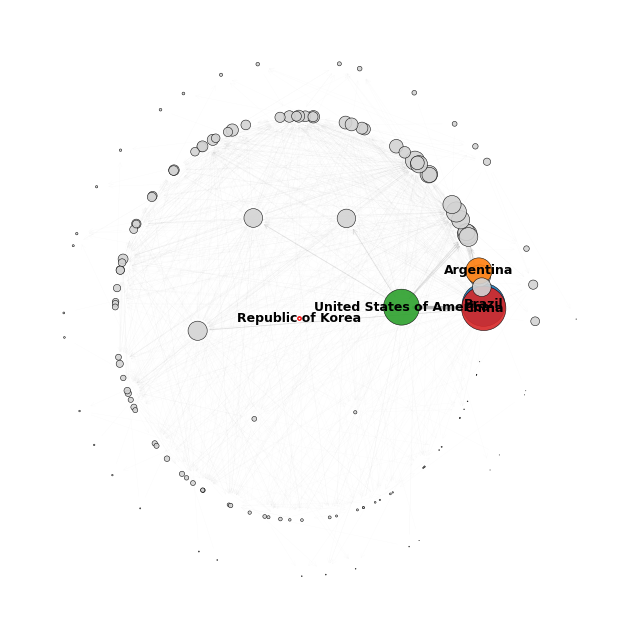

In [20]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

# ======================================================
# 기본 설정
# ======================================================
plt.figure(figsize=(6.5, 6.5))
rng = np.random.default_rng(42)

# ======================================================
# 1. 한국 노드 찾기
# ======================================================
korea_names = [
    "Korea, Rep.",
    "South Korea",
    "Republic of Korea",
    "Korea"
]

korea_node = None
for name in korea_names:
    if name in G.nodes():
        korea_node = name
        break

if korea_node is None:
    raise ValueError("한국 노드를 찾지 못했습니다.")

# ======================================================
# 2. 한국 기준 hop 거리 (방향 무시)
# ======================================================
hop_dist = nx.single_source_shortest_path_length(
    G.to_undirected(),
    source=korea_node
)

max_hop = max(hop_dist.values())
for n in G.nodes():
    if n not in hop_dist:
        hop_dist[n] = max_hop + 1

# ======================================================
# 3. hop → 반지름 매핑
# ======================================================
radius_map = {
    0: 0,
    1: 10,
    2: 18,
    3: 23,
    4: 27,
}

def map_radius(d):
    if d in radius_map:
        return radius_map[d]
    else:
        return radius_map[4] + 3 * (d - 4)

# ======================================================
# 4. 방사형 좌표 (같은 반지름 내 겹침 방지)
# ======================================================
pos = {korea_node: (0, 0)}

by_hop = {}
for n in G.nodes():
    if n == korea_node:
        continue
    by_hop.setdefault(hop_dist[n], []).append(n)

for d, nodes_d in by_hop.items():
    r = map_radius(d)
    k = len(nodes_d)
    if k == 0:
        continue

    # 균등 분포 + 미세 노이즈 (겹침 방지)
    theta_base = np.linspace(0, 2*np.pi, k, endpoint=False)
    theta_noise = rng.uniform(-0.12, 0.12, k)
    theta = theta_base + theta_noise

    for i, n in enumerate(nodes_d):
        pos[n] = (
            r * np.cos(theta[i]),
            r * np.sin(theta[i])
        )

# ======================================================
# 5. 노드 크기 (총 교역량)
# ======================================================
out_wdeg = dict(G.out_degree(weight="weight"))
in_wdeg  = dict(G.in_degree(weight="weight"))

total_trade = {
    n: out_wdeg.get(n, 0) + in_wdeg.get(n, 0)
    for n in G.nodes()
}

node_size = [
    np.sqrt(total_trade[n]) / 10
    for n in G.nodes()
]

# ======================================================
# 6. 간선 스타일
#   - 한국으로 들어오는 1-hop만 빨간색
#   - 전체 두께 축소
# ======================================================
edges_normal = []
edges_korea  = []

edge_width_normal = []
edge_alpha_normal = []

edge_width_korea = []
edge_alpha_korea = []

max_w = max(G[u][v]["weight"] for u, v in G.edges())

for u, v in G.edges():
    ratio = G[u][v]["weight"] / max_w

    # 🔴 한국으로 들어오는 간선만 강조
    if v == korea_node:
        edges_korea.append((u, v))
        edge_width_korea.append(1.8)
        edge_alpha_korea.append(0.85)
    else:
        edges_normal.append((u, v))

        if ratio < 0.02:
            edge_width_normal.append(0.2); edge_alpha_normal.append(0.05)
        elif ratio < 0.1:
            edge_width_normal.append(0.6); edge_alpha_normal.append(0.20)
        elif ratio < 0.3:
            edge_width_normal.append(1.4); edge_alpha_normal.append(0.35)
        else:
            edge_width_normal.append(2.5); edge_alpha_normal.append(0.55)

# 일반 간선
nx.draw_networkx_edges(
    G, pos,
    edgelist=edges_normal,
    arrowstyle="->",
    arrowsize=8,
    width=edge_width_normal,
    alpha=edge_alpha_normal,
    edge_color="gray"
)

# 한국 직결 간선
nx.draw_networkx_edges(
    G, pos,
    edgelist=edges_korea,
    arrowstyle="->",
    arrowsize=9,
    width=edge_width_korea,
    alpha=edge_alpha_korea,
    edge_color="red"
)

# ======================================================
# 7. 노드 색상 (국가별 강조)
# ======================================================
special_colors = {
    korea_node: "white",
    "United States of America": "#2ca02c",  # 미국
    "Brazil": "#1f77b4",                    # 브라질
    "Argentina": "#ff7f0e",                 # 아르헨티나
    "China, mainland": "#d62728",           # 중국
}

node_color = [
    special_colors.get(n, "lightgray")
    for n in G.nodes()
]

nx.draw_networkx_nodes(
    G, pos,
    node_size=node_size,
    node_color=node_color,
    edgecolors="black",
    linewidths=0.4,
    alpha=0.9
)

# ======================================================
# 8. 한국 노드 테두리 강조 (라벨 중복 없음)
# ======================================================
nx.draw_networkx_nodes(
    G, pos,
    nodelist=[korea_node],
    node_size=[np.sqrt(total_trade[korea_node]) / 6],
    node_color="white",
    edgecolors="red",
    linewidths=2.5,
    alpha=1.0
)

# ======================================================
# 9. 주요 국가 라벨
# ======================================================
label_targets = [
    korea_node,
    "United States of America",
    "Brazil",
    "Argentina",
    "China, mainland"
]

for n in label_targets:
    if n in pos:
        x, y = pos[n]
        plt.text(
            x, y,
            n.split(",")[0],
            fontsize=9,
            ha="center",
            va="center",
            fontweight="bold"
        )

# ======================================================
# 마무리
# ======================================================
plt.axis("off")
plt.tight_layout()
plt.show()


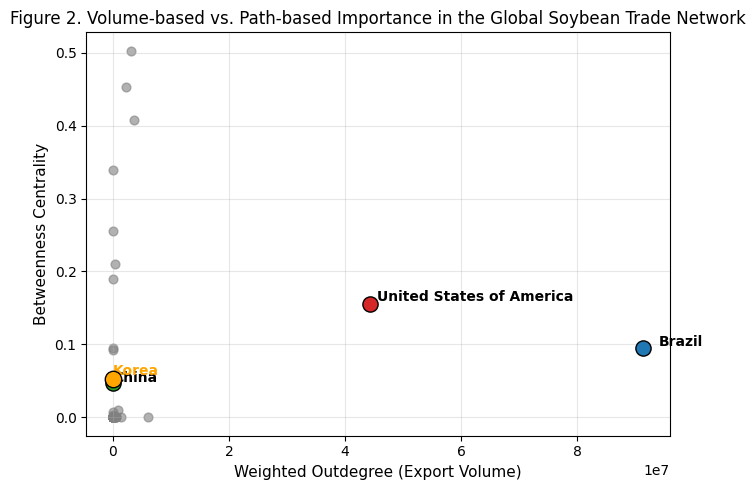

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# =========================
# 1. x, y 데이터 준비
# =========================
countries = list(G.nodes())

# x축: weighted outdegree (또는 total)
x = np.array([
    out_wdeg.get(c, 0) for c in countries
])

# y축: betweenness centrality
y = np.array([
    bc.get(c, 0) for c in countries
])

# =========================
# 2. 산점도
# =========================
plt.figure(figsize=(7, 5))

plt.scatter(
    x, y,
    s=40,
    alpha=0.6,
    color="gray"
)

# =========================
# 3. 핵심 국가 강조
# =========================
key_countries = ["Brazil", "United States of America", "China, mainland"]
key_colors = {
    "Brazil": "#1f77b4",
    "United States of America": "#d62728",
    "China, mainland": "#2ca02c",
}

for c in key_countries:
    if c in countries:
        xi = out_wdeg.get(c, 0)
        yi = bc.get(c, 0)

        plt.scatter(
            xi, yi,
            s=120,
            color=key_colors[c],
            edgecolors="black",
            zorder=3
        )

        plt.text(
            xi * 1.03,
            yi * 1.03,
            c.replace(", mainland", ""),
            fontsize=10,
            fontweight="bold"
        )

# =========================
# 3-1. 한국 강조
# =========================
korea_names = [
    "Korea",
    "Republic of Korea",
    "Korea, Rep.",
    "South Korea"
]

korea = next((k for k in korea_names if k in countries), None)

if korea is not None:
    xk = out_wdeg.get(korea, 0)
    yk = bc.get(korea, 0)

    plt.scatter(
        xk, yk,
        s=140,
        color="orange",
        edgecolors="black",
        zorder=4
    )

    plt.text(
        xk + 0.1,
        yk + 0.005,
        "Korea",
        fontsize=10,
        fontweight="bold",
        color="orange"
    )
else:
    print("⚠️ 한국 노드를 찾지 못했습니다. 노드 이름을 확인하세요.")


# =========================
# 4. 축 & 스타일
# =========================
plt.xlabel("Weighted Outdegree (Export Volume)", fontsize=11)
plt.ylabel("Betweenness Centrality", fontsize=11)

plt.title(
    "Figure 2. Volume-based vs. Path-based Importance in the Global Soybean Trade Network",
    fontsize=12
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# import matplotlib as mpl

# mpl.use("pgf")

# mpl.rcParams.update({
#     "pgf.texsystem": "xelatex",   # lualatex도 가능
#     "text.usetex": True,
#     "font.family": "serif",
#     "font.serif": ["Times New Roman"],  # 논문 기본 폰트
#     "axes.unicode_minus": False,
# })


# plt.savefig("asset/soybean_central_outdegree.pgf")
# plt.close()


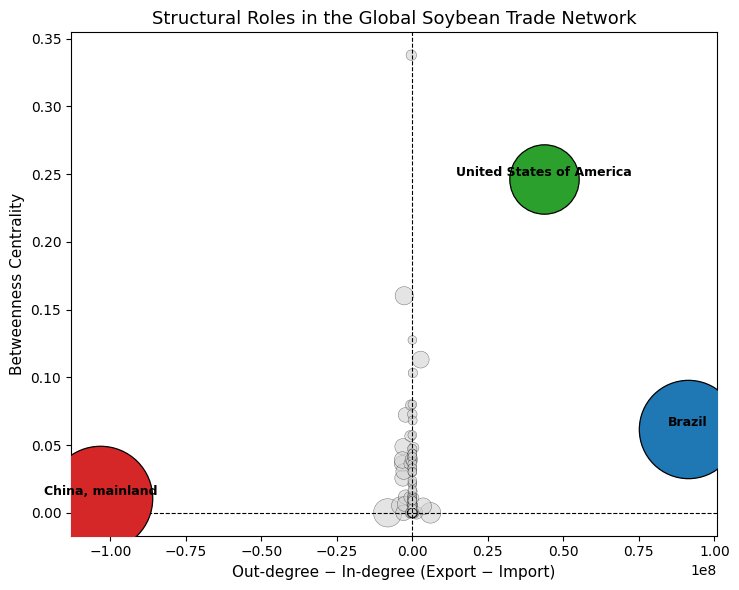

In [22]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# ======================================================
# 0. LaTeX (PGF) 설정 — 논문용
# ======================================================
# mpl.use("pgf")
# mpl.rcParams.update({
#     "pgf.texsystem": "xelatex",
#     "text.usetex": True,
#     "font.family": "serif",
#     "font.serif": ["Times New Roman"],
#     "axes.unicode_minus": False,
# })

# ======================================================
# 1. 네트워크 준비 (이미 G가 있다고 가정)
#    G: DiGraph, edge["weight"] = trade volume
# ======================================================

# -------------------------
# 가중 in / out degree
# -------------------------
out_wdeg = dict(G.out_degree(weight="weight"))
in_wdeg  = dict(G.in_degree(weight="weight"))

# -------------------------
# 매개 중심성
# -------------------------
bc = nx.betweenness_centrality(
    G,
    weight="weight",
    normalized=True
)

# ======================================================
# 2. 좌표 계산
# ======================================================
nodes = list(G.nodes())

x = np.array([
    out_wdeg.get(n, 0) - in_wdeg.get(n, 0)
    for n in nodes
])

y = np.array([
    bc.get(n, 0)
    for n in nodes
])

# ======================================================
# 3. 노드 크기 (총 교역량)
# ======================================================
total_trade = {
    n: out_wdeg.get(n, 0) + in_wdeg.get(n, 0)
    for n in nodes
}

node_size = np.array([
    40 + 0.00003 * total_trade[n]
    for n in nodes
])

# ======================================================
# 4. 기본 산점도
# ======================================================
plt.figure(figsize=(7.5, 6))

plt.scatter(
    x, y,
    s=node_size,
    color="lightgray",
    alpha=0.6,
    edgecolor="black",
    linewidth=0.3,
    zorder=1
)

# ======================================================
# 5. 기준선 (사분면)
# ======================================================
plt.axvline(0, color="black", linestyle="--", linewidth=0.8)
plt.axhline(0, color="black", linestyle="--", linewidth=0.8)

# ======================================================
# 6. 핵심 국가 강조
# ======================================================
key_countries = {
    "China, mainland": "#d62728",          # 중국 (수입 중심)
    "Brazil": "#1f77b4",                   # 브라질 (수출 중심)
    "United States of America": "#2ca02c"  # 미국 (수출 + 중개)
}

for country, color in key_countries.items():
    if country in nodes:
        i = nodes.index(country)
        plt.scatter(
            x[i], y[i],
            s=node_size[i] * 1.8,
            color=color,
            edgecolor="black",
            linewidth=0.9,
            zorder=3
        )
        plt.text(
            x[i],
            y[i],
            country,
            fontsize=9,
            ha="center",
            va="bottom",
            fontweight="bold"
        )

# ======================================================
# 7. 축 / 제목
# ======================================================
plt.xlabel(
    "Out-degree − In-degree (Export − Import)",
    fontsize=11
)

plt.ylabel(
    "Betweenness Centrality",
    fontsize=11
)

plt.title(
    "Structural Roles in the Global Soybean Trade Network",
    fontsize=13
)

plt.tight_layout()

# ======================================================
# 8. 저장 (LaTeX 바로 삽입 가능)
# ======================================================

plt.show()

# plt.savefig(
#     "/home/user/문서/workspace/latex/project/paper/agri_develope/asset/"
#     "soybean_structural_roles.pgf"
# )

# plt.close()


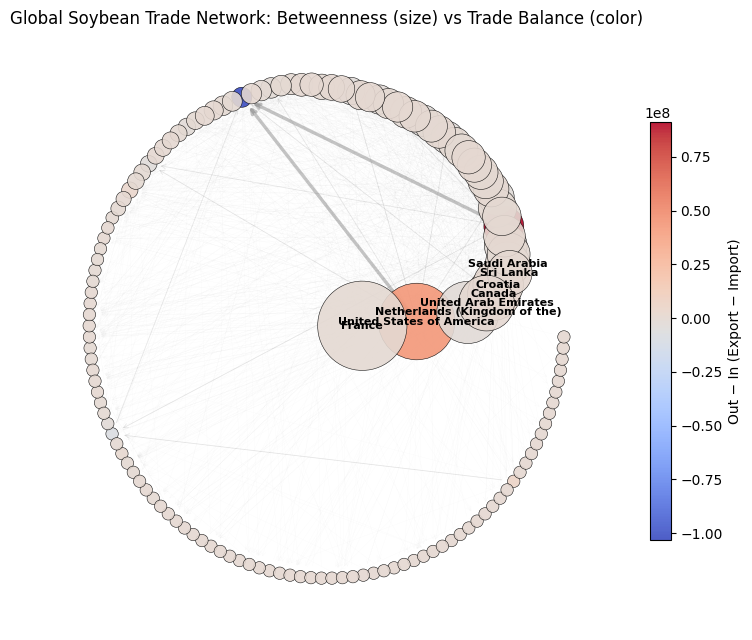

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

# 1) 지표
bc = nx.betweenness_centrality(G, weight="weight", normalized=True)
out_wdeg = dict(G.out_degree(weight="weight"))
in_wdeg  = dict(G.in_degree(weight="weight"))

nodes = list(G.nodes())

# 2) 노드 크기 = 매개 중심성 (차이 과감히)
bc_vals = np.array([bc.get(n, 0.0) for n in nodes])
node_size = 80 + 12000 * bc_vals  # <- 필요하면 12000만 조정

# 3) 노드 색 = 순교역 방향성 (수출-수입)
x_balance = np.array([out_wdeg.get(n, 0) - in_wdeg.get(n, 0) for n in nodes])

# ======================================================
# 4) 레이아웃: betweenness 기반 방사형 (겹침 방지)
# ======================================================

# betweenness 정규화 (0~1)
bc_norm = (bc_vals - bc_vals.min()) / (bc_vals.max() - bc_vals.min() + 1e-9)

# 중심에 가까울수록 큰 bc
# r = 0 (중심) ~ 1 (외곽)
r_base = 1.0 - bc_norm

# 노드 크기를 반영해 최소 반지름 보정
# (큰 노드는 약간 더 바깥으로)
size_norm = (node_size - np.min(node_size)) / (np.max(node_size) - np.min(node_size) + 1e-9)
r = r_base + 0.15 * size_norm

# bc 큰 순서대로 정렬
order = np.argsort(-bc_norm)

pos = {}

# 같은 반지름대(ring)에서 겹치지 않도록 각도 분산
num_nodes = len(nodes)
theta = np.linspace(0, 2*np.pi, num_nodes, endpoint=False)

for rank, idx in enumerate(order):
    n = nodes[idx]

    # 각도는 순서대로 배치
    angle = theta[rank]

    # 반지름 스케일링 (그림 크기에 맞춤)
    rr = r[idx] * 10.0

    pos[n] = (
        rr * np.cos(angle),
        rr * np.sin(angle)
    )


# 5) 엣지 스타일 (교역량 비율 기반 얇게)
max_w = max(G[u][v]["weight"] for u, v in G.edges())
edge_w = []
edge_a = []
edgelist = []

for u, v in G.edges():
    ratio = G[u][v]["weight"] / max_w
    edgelist.append((u, v))
    if ratio < 0.02:
        edge_w.append(0.2); edge_a.append(0.05)
    elif ratio < 0.1:
        edge_w.append(0.6); edge_a.append(0.18)
    elif ratio < 0.3:
        edge_w.append(1.4); edge_a.append(0.30)
    else:
        edge_w.append(2.4); edge_a.append(0.45)

plt.figure(figsize=(7.5, 6.5))

nx.draw_networkx_edges(
    G, pos, edgelist=edgelist,
    width=edge_w, alpha=edge_a,
    edge_color="gray", arrows=True,
    arrowstyle="->", arrowsize=8
)

# 노드: 색은 x_balance를 연속값으로 매핑 (수입/수출 구분이 직관적)
sc = nx.draw_networkx_nodes(
    G, pos,
    nodelist=nodes,
    node_size=node_size,
    node_color=x_balance,
    cmap="coolwarm",  # <- 수입(음) vs 수출(양) 대비
    edgecolors="black",
    linewidths=0.4,
    alpha=0.9
)

plt.colorbar(sc, shrink=0.7, label="Out − In (Export − Import)")

# 상위 매개 중심성 라벨링 (네 문단과 직접 연결)
top_bc = sorted(nodes, key=lambda n: bc.get(n, 0), reverse=True)[:8]
for n in top_bc:
    x, y = pos[n]
    plt.text(x, y, n, fontsize=8, ha="center", va="center", fontweight="bold")

plt.title("Global Soybean Trade Network: Betweenness (size) vs Trade Balance (color)")
plt.axis("off")
plt.tight_layout()
plt.show()


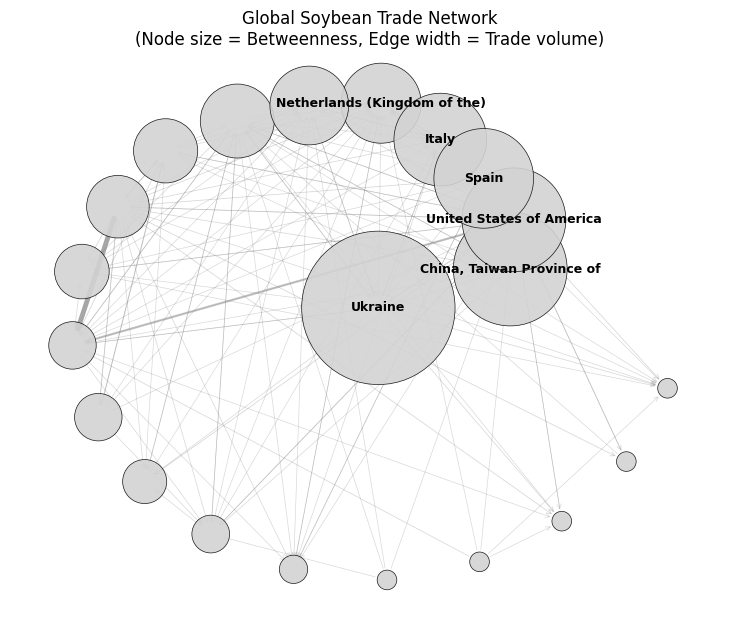

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

# ======================================================
# 1. 상위 20개 + 한국 포함
# ======================================================
out_wdeg = dict(G.out_degree(weight="weight"))
in_wdeg  = dict(G.in_degree(weight="weight"))

total_trade = {
    n: out_wdeg.get(n, 0) + in_wdeg.get(n, 0)
    for n in G.nodes()
}

top20 = sorted(total_trade, key=total_trade.get, reverse=True)[:20]

korea_names = ["Korea, Rep.", "Republic of Korea", "South Korea", "Korea"]
korea_node = next(k for k in korea_names if k in G.nodes())

if korea_node not in top20:
    top20.append(korea_node)

G_sub = G.subgraph(top20).copy()
nodes = list(G_sub.nodes())

# ======================================================
# 2. 지표 계산 (서브그래프 기준)
# ======================================================
bc = nx.betweenness_centrality(G_sub, weight="weight", normalized=True)
out_wdeg = dict(G_sub.out_degree(weight="weight"))
in_wdeg  = dict(G_sub.in_degree(weight="weight"))

# ======================================================
# 3. 노드 크기 = 매개 중심성
# ======================================================
bc_vals = np.array([bc.get(n, 0.0) for n in nodes])

node_size = (
    200 + 12000 * (bc_vals / (bc_vals.max() + 1e-9))
)

# ======================================================
# 4. 레이아웃: betweenness → 반지름
# ======================================================
bc_norm = bc_vals / (bc_vals.max() + 1e-9)
order = np.argsort(-bc_norm)

pos = {}
theta = np.linspace(0, 2*np.pi, len(nodes), endpoint=False)

for rank, idx in enumerate(order):
    n = nodes[idx]
    r = (1 - bc_norm[idx]) * 10 + 0.5  # 중심 집중 + 최소 간격
    pos[n] = (r * np.cos(theta[rank]), r * np.sin(theta[rank]))

# ======================================================
# 5. 간선 두께 = 교역 규모
# ======================================================
max_w = max(G_sub[u][v]["weight"] for u, v in G_sub.edges())

edge_width = []
edge_alpha = []
edgelist = []

for u, v in G_sub.edges():
    w = G_sub[u][v]["weight"]
    ratio = w / max_w

    edgelist.append((u, v))
    edge_width.append(0.5 + 3.0 * ratio)   # ⬅ 교역 규모 반영
    edge_alpha.append(0.3 + 0.4 * ratio)

# ======================================================
# 6. 그리기
# ======================================================
plt.figure(figsize=(7.5, 6.5))

nx.draw_networkx_edges(
    G_sub, pos,
    edgelist=edgelist,
    width=edge_width,
    alpha=edge_alpha,
    edge_color="gray",
    arrows=True,
    arrowstyle="->",
    arrowsize=8
)

nx.draw_networkx_nodes(
    G_sub, pos,
    nodelist=nodes,
    node_size=node_size,
    node_color="lightgray",
    edgecolors="black",
    linewidths=0.5,
    alpha=0.9
)

# ======================================================
# 7. 상위 매개 중심성 국가 라벨
# ======================================================
top_bc = sorted(nodes, key=lambda n: bc.get(n, 0), reverse=True)[:6]
for n in top_bc:
    x, y = pos[n]
    plt.text(x, y, n, fontsize=9, ha="center", va="center", fontweight="bold")

plt.title("Global Soybean Trade Network\n(Node size = Betweenness, Edge width = Trade volume)")
plt.axis("off")
plt.tight_layout()
plt.show()
